In [2]:
import pandas as pd

df = pd.read_parquet("/home/nabin2004/Desktop/projects/lichess/data/processed/2013-01.parquet")
print(df.shape, df.columns.tolist())

(121332, 18) ['event', 'site', 'date', 'round', 'white', 'black', 'result', 'utc_date', 'utc_time', 'white_elo', 'black_elo', 'white_rating_diff', 'black_rating_diff', 'eco', 'opening', 'time_control', 'termination', 'moves']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121332 entries, 0 to 121331
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   event              121332 non-null  str    
 1   site               121332 non-null  str    
 2   date               121332 non-null  str    
 3   round              121332 non-null  str    
 4   white              121332 non-null  str    
 5   black              121332 non-null  str    
 6   result             121332 non-null  str    
 7   utc_date           121332 non-null  str    
 8   utc_time           121332 non-null  str    
 9   white_elo          121254 non-null  float64
 10  black_elo          121192 non-null  float64
 11  white_rating_diff  121114 non-null  float64
 12  black_rating_diff  121114 non-null  float64
 13  eco                121332 non-null  str    
 14  opening            121332 non-null  str    
 15  time_control       121332 non-null  str    
 16  termination  

<Axes: >

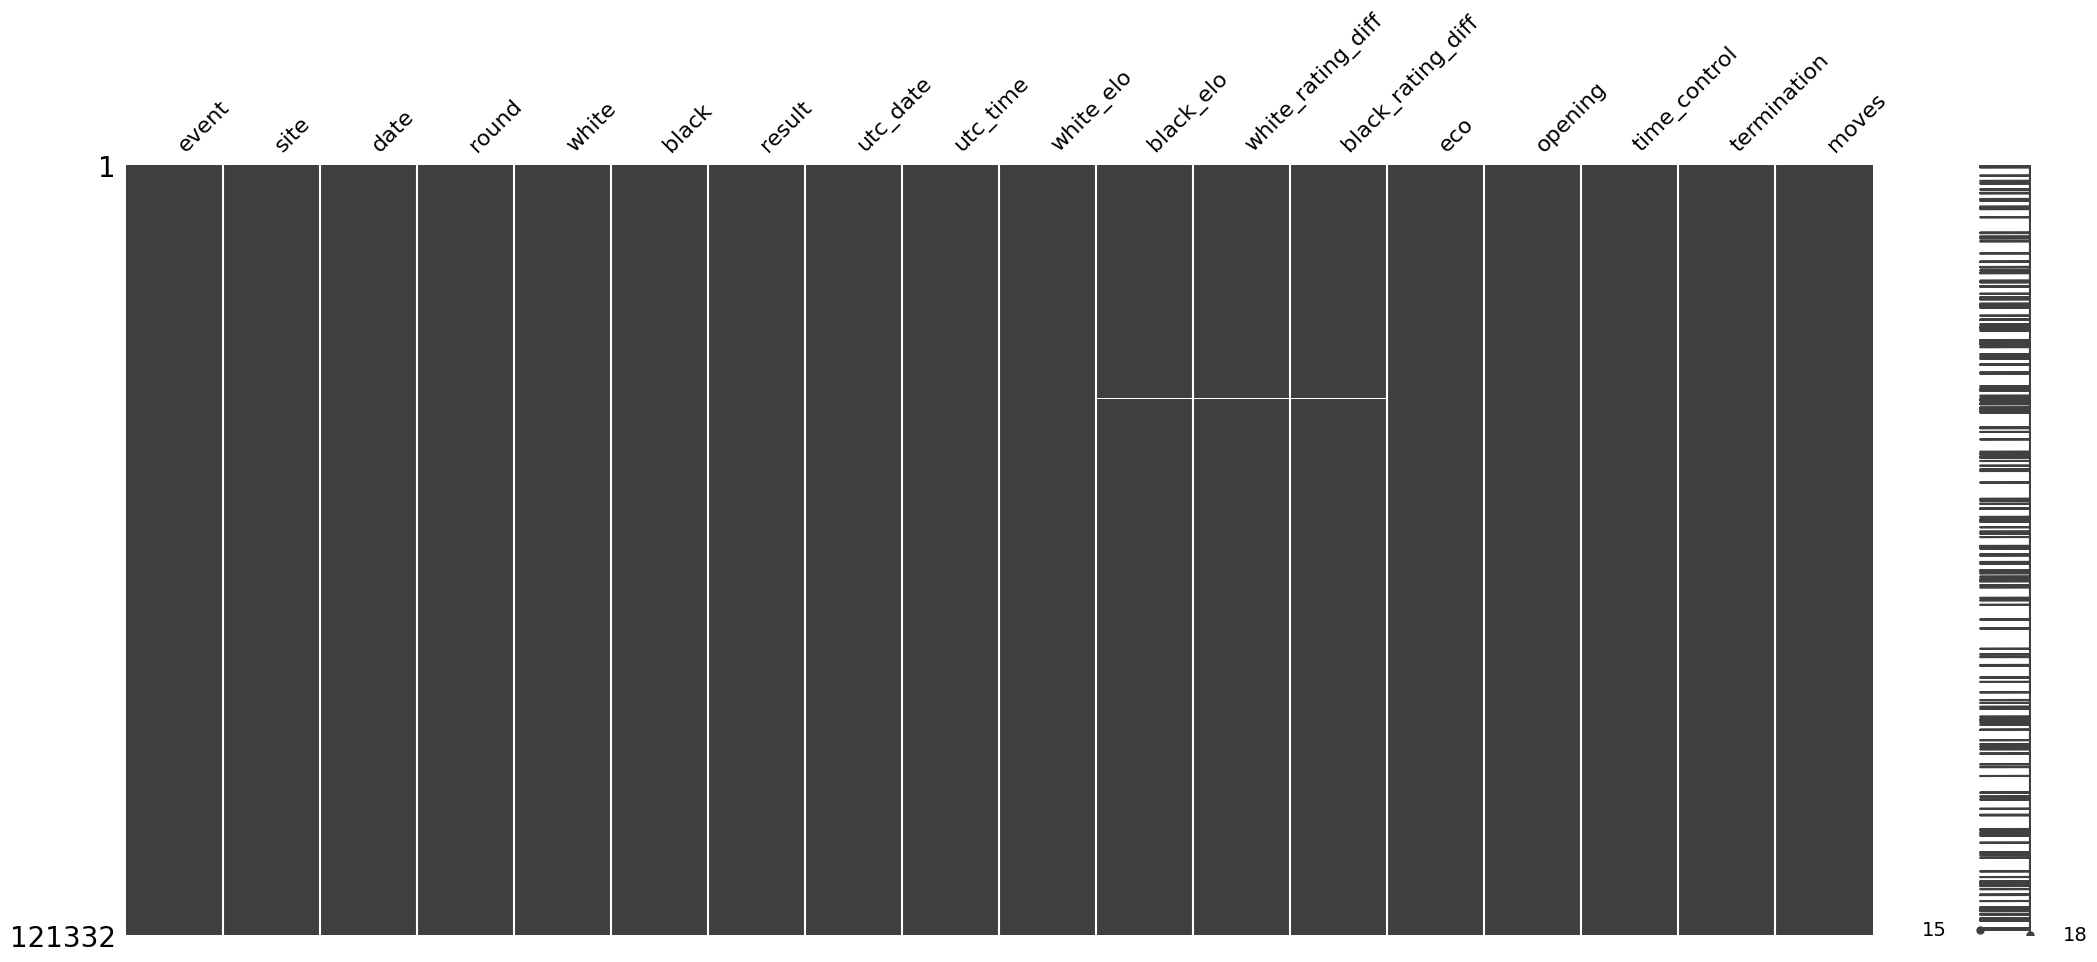

In [4]:
import missingno as msno
msno.matrix(df)

In [6]:
def find_missing_values(df):
    missing_values = df.isnull().sum()
    print("Missing values in each column:")
    print(missing_values)
    
find_missing_values(df)

Missing values in each column:
event                  0
site                   0
date                   0
round                  0
white                  0
black                  0
result                 0
utc_date               0
utc_time               0
white_elo             78
black_elo            140
white_rating_diff    218
black_rating_diff    218
eco                    0
opening                0
time_control           0
termination            0
moves                  0
dtype: int64


# Each columns inspection

In [10]:
df["event"].unique()

<ArrowStringArray>
[                                           'Rated Classical game',
                                               'Rated Bullet game',
                                                'Rated Blitz game',
                                       'Rated Correspondence game',
  'Rated Blitz tournament https://lichess.org/tournament/vgl66r66',
 'Rated Bullet tournament https://lichess.org/tournament/q7b7qhl2',
 'Rated Bullet tournament https://lichess.org/tournament/whvcsoro',
  'Rated Blitz tournament https://lichess.org/tournament/cp716zap',
 'Rated Bullet tournament https://lichess.org/tournament/1hzj7nct',
 'Rated Bullet tournament https://lichess.org/tournament/0hb48t81',
 ...
  'Rated Blitz tournament https://lichess.org/tournament/bwdi1k3e',
 'Rated Bullet tournament https://lichess.org/tournament/ncy6reb3',
 'Rated Bullet tournament https://lichess.org/tournament/a4ysc62l',
 'Rated Bullet tournament https://lichess.org/tournament/k7d4khyy',
  'Rated Blitz tournamen

In [11]:
df[["event_name", "tournament_url"]] = (
    df["event"]
    .astype("string")
    .str.extract(
        r"^(?P<event_name>.*?)(?:\s+(?P<tournament_url>https://\S+))?$"
    )
)

df["event_name"] = df["event_name"].str.strip()

In [12]:
df['event_name'].value_counts()

event_name
Rated Blitz game              45388
Rated Classical game          41772
Rated Bullet game             32691
Rated Blitz tournament          896
Rated Bullet tournament         295
Rated Correspondence game       266
Rated Classical tournament       24
Name: count, dtype: int64[pyarrow]

In [14]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 121332 entries, 0 to 121331
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   event              121332 non-null  str    
 1   site               121332 non-null  str    
 2   date               121332 non-null  str    
 3   round              121332 non-null  str    
 4   white              121332 non-null  str    
 5   black              121332 non-null  str    
 6   result             121332 non-null  str    
 7   utc_date           121332 non-null  str    
 8   utc_time           121332 non-null  str    
 9   white_elo          121254 non-null  float64
 10  black_elo          121192 non-null  float64
 11  white_rating_diff  121114 non-null  float64
 12  black_rating_diff  121114 non-null  float64
 13  eco                121332 non-null  str    
 14  opening            121332 non-null  str    
 15  time_control       121332 non-null  str    
 16  termination  

Event: Didn't found any missing values
site: Some are empty but it works as this variable won't be used in model training
date: Is empty. But I think we have utc_date column
round: All are ?, I think most probably it means zero.


In [17]:
df['tournament_url'].unique()

<ArrowStringArray>
[                                     <NA>,
 'https://lichess.org/tournament/vgl66r66',
 'https://lichess.org/tournament/q7b7qhl2',
 'https://lichess.org/tournament/whvcsoro',
 'https://lichess.org/tournament/cp716zap',
 'https://lichess.org/tournament/1hzj7nct',
 'https://lichess.org/tournament/0hb48t81',
 'https://lichess.org/tournament/bsr33p8n',
 'https://lichess.org/tournament/nyqb36b9',
 'https://lichess.org/tournament/qrl35w21',
 ...
 'https://lichess.org/tournament/bwdi1k3e',
 'https://lichess.org/tournament/ncy6reb3',
 'https://lichess.org/tournament/a4ysc62l',
 'https://lichess.org/tournament/k7d4khyy',
 'https://lichess.org/tournament/va5vmfwk',
 'https://lichess.org/tournament/lz62uwix',
 'https://lichess.org/tournament/7qcfytwx',
 'https://lichess.org/tournament/uitsh1pw',
 'https://lichess.org/tournament/wlvsn5j1',
 'https://lichess.org/tournament/j7mqmtp5']
Length: 148, dtype: string

In [20]:
df['date'].unique()

<ArrowStringArray>
['????.??.??']
Length: 1, dtype: str

In [22]:
df["round"].unique()

<ArrowStringArray>
['?']
Length: 1, dtype: str

In [23]:
df['white'].unique()

<ArrowStringArray>
[           'BFG9k',   'Desmond_Wilson',    'Kozakmamay007',
 'Naitero_Nagasaki',     'nichiren1967',            'sport',
          'tiggran',         'hostking',          'manos68',
          'adamsrj',
 ...
            'vadi2',          'susanin',    'TheFireOfDoom',
            'senip',       'pravousrce',  'The_Black_Rider',
 'WhyDidThisHappen',        'EpicmanNY',         'XXJEARXX',
            'Daler']
Length: 4247, dtype: str

In [25]:
df['black'].unique()

<ArrowStringArray>
[            'mamalak',           'savinka59',   'VanillaShamanilla',
                 '800',    'Naitero_Nagasaki',            'shamirbj',
             'arion_6',          'troepianiz',           'jtkjtkful',
            'hamiakaz',
 ...
          'ChessBacon',              'ashnur',            'absfresh',
          'AqibNabi01',     'The_Black_Rider', 'franciscohemeroteca',
              'gonsar',          'nabiaqib01',                '1620',
          'pravousrce']
Length: 4195, dtype: str

In [27]:
df['result'].unique()

<ArrowStringArray>
['1-0', '0-1', '1/2-1/2']
Length: 3, dtype: str

In [28]:
df['utc_date']

0         2012.12.31
1         2012.12.31
2         2012.12.31
3         2012.12.31
4         2012.12.31
             ...    
121327    2013.01.31
121328    2013.01.31
121329    2013.01.31
121330    2013.01.31
121331    2013.01.31
Name: utc_date, Length: 121332, dtype: str

In [29]:
df['utc_time']

0         23:01:03
1         23:04:12
2         23:03:15
3         23:04:57
4         23:02:37
            ...   
121327    22:59:08
121328    22:59:13
121329    22:59:27
121330    22:59:41
121331    22:59:31
Name: utc_time, Length: 121332, dtype: str

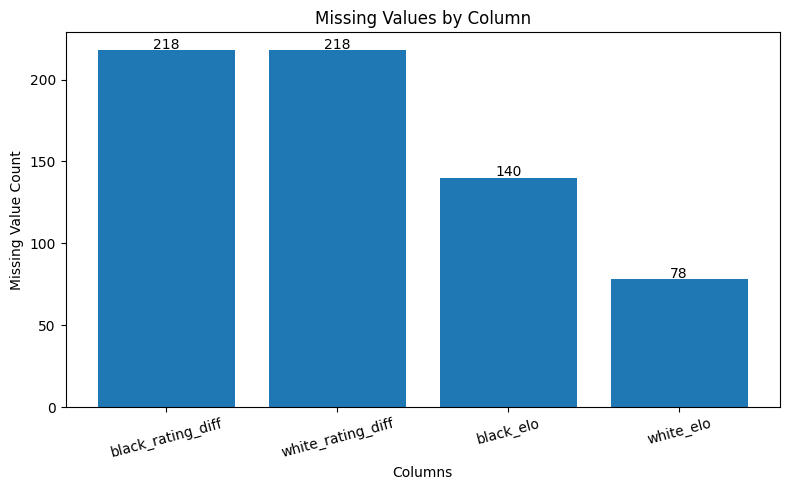

In [30]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_missing_values(df: pd.DataFrame, columns: list[str]) -> None:
    """
    Plot missing value counts for selected columns.
    """

    missing_counts = df[columns].isna().sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    plt.bar(missing_counts.index, missing_counts.values)

    plt.xlabel("Columns")
    plt.ylabel("Missing Value Count")
    plt.title("Missing Values by Column")

    plt.xticks(rotation=15)

    for i, value in enumerate(missing_counts.values):
        plt.text(i, value + 1, str(value), ha="center")

    plt.tight_layout()
    plt.show()


rating_cols = [
    "white_elo",
    "black_elo",
    "white_rating_diff",
    "black_rating_diff",
]

plot_missing_values(df, rating_cols)

# Weird#1
Why does the addition of black_elo and white_elo sum becomes the number of black_rating_diff and white_rating_diff. This appears weird to me.
Maybe, I should understand what is elo and how it is calculated.